In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import imageio.v2 as imageio
import os
import tempfile
from scipy.optimize import curve_fit

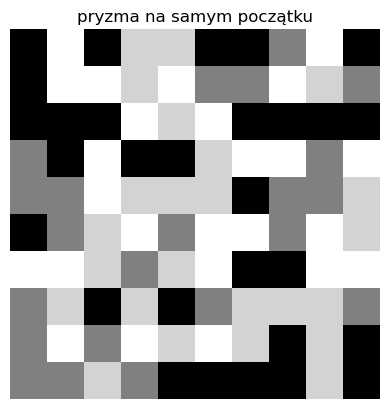

In [21]:
dane_mapa_zadanie1 = np.loadtxt('pryzmy1.dat')
shape = np.shape(dane_mapa_zadanie1)

dane_mapa_zadanie1 = np.split(dane_mapa_zadanie1, shape[0]/shape[1])
cmap = ListedColormap(['white', 'lightgray', 'gray', 'black'])
plt.imshow(dane_mapa_zadanie1[0], cmap=cmap)
plt.axis('off')
plt.title('pryzma na samym początku')
plt.savefig('pryzma_na_poczatku.pdf')
plt.show()

with tempfile.TemporaryDirectory() as temp_dir:
    frames = []
    for i in range(len(dane_mapa_zadanie1)):
        plt.imshow(dane_mapa_zadanie1[i], cmap=cmap)
        plt.axis('off')

        temp_filename = os.path.join(temp_dir, f"frame_{i}.png")
        plt.savefig(temp_filename, bbox_inches='tight', pad_inches=0)
        plt.close()

        frames.append(imageio.imread(temp_filename))

    imageio.mimsave('sand.gif', frames, duration=0.5)

In [ ]:
dane_mapa_zadanie2 = np.loadtxt('pryzmy2.dat')
shape = np.shape(dane_mapa_zadanie2)

dane_mapa_zadanie2 = np.split(dane_mapa_zadanie2, shape[0]/shape[1])
cmap = ListedColormap(['white', 'lightgray', 'gray', 'black'])

with tempfile.TemporaryDirectory() as temp_dir:
    frames = []
    for i in range(200): # len(dane_mapa_zadanie2)
        plt.imshow(dane_mapa_zadanie2[i], cmap=cmap)
        plt.axis('off')

        temp_filename = os.path.join(temp_dir, f"frame_{i}.png")
        plt.savefig(temp_filename, bbox_inches='tight', pad_inches=0)
        plt.close()

        frames.append(imageio.imread(temp_filename))

    imageio.mimsave('sand_long.gif', frames, duration=0.5)

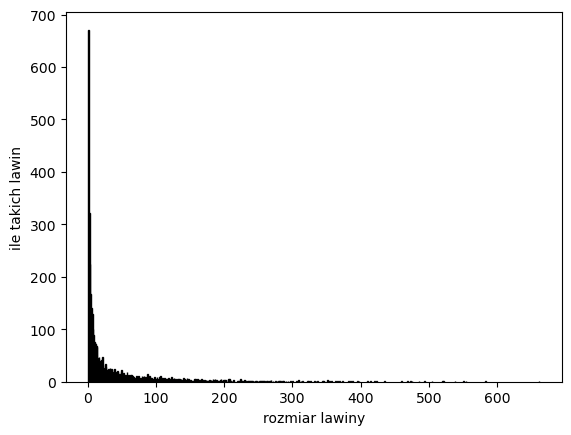

tau = 1.1857317901894278
u(tau) = 0.02325622699359356


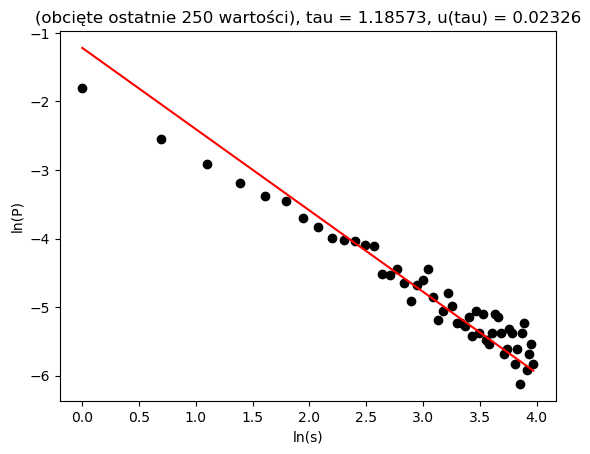

In [19]:
from scipy.optimize import curve_fit

dane_zadanie2 = np.loadtxt('s2.dat')


unique_values = np.unique(dane_zadanie2)
how_many_each = np.array([np.sum(dane_zadanie2 == value) for value in unique_values])

unique_values = unique_values[1:]
how_many_each = how_many_each[1:]

plt.bar(unique_values, how_many_each, width=1, edgecolor="black", align="edge")
plt.xlabel('rozmiar lawiny')
plt.ylabel('ile takich lawin')
plt.savefig('histogram.pdf')
plt.show()

P = how_many_each/np.sum(how_many_each)






log_unique_values = np.log(unique_values)
log_P = np.log(P)

def linear(x, a, b):
    return a*x + b

popt, pcov = curve_fit(linear, log_unique_values, log_P)

tau = -popt[0]
u_tau = np.sqrt(np.diag(pcov))[0]

print(f"tau = {tau}")
print(f"u(tau) = {u_tau}")

plt.scatter(log_unique_values[:-250], log_P[:-250], color="k")
plt.plot(log_unique_values[:-250], linear(log_unique_values[:-250], *popt), color="red")
plt.xlabel("ln(s)")
plt.ylabel("ln(P)")
plt.title(f"(obcięte ostatnie 250 wartości), tau = {tau:.6}" + f", u(tau) = {u_tau:.4}")
plt.savefig('dopasowanie.pdf')
plt.show()
